In [1]:
pip install dcor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.9 MB/s eta 0:00:00


In [2]:
pip install pymongo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 28.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import certifi
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import dcor

## Query the data

In [4]:
def query_mongodb(uri="blured", collection_name="vix_data", db_name="DB_VIX", filtro=None):
    client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

    db = client[db_name]
    collection = db[collection_name]

    filtro = filtro or {}

    # bring data
    docs = list(collection.find(filtro))

    if not docs:
        return pd.DataFrame()  # return a n empty df if there is no data

    df = pd.DataFrame(docs)

    # transform _id to datetime
    if "_id" in df.columns:
        df["_id"] = pd.to_datetime(df["_id"])
        df.set_index("_id", inplace=True)

    return df

### Data

In [5]:
df= query_mongodb()
df.tail()

,DXY_overnight,Drawdown,GOLD_overnight,IV_RV_Ratio,Intraday_VIX_Move,Momentum_1M,Momentum_3M,Momentum_6M,OIL_overnight,Open_DXY,...,VIX_Percentile,VIX_RV_Spread,VIX_STD_10,VIX_STD_5,VIX_Trend,VIX_Vol_10d,VIX_Vol_21d,VIX_Vol_5d,VIX_Zscore,VIX_Zscore_Sq
_id,,,,,,,,,,,,,,,,,,,,,
2026-03-23,0.000301,-0.067653,-0.047567,199.586568,2,-0.051795,-0.058368,-0.014874,0.022274,99.680000,...,0.928571,26.645823,1.632818,1.670470,3.016884,0.097292,0.102365,0.111692,1.095159,1.199373
2026-03-24,0.001920,-0.056974,-0.014850,188.128728,1,-0.047545,-0.050642,-0.009438,0.007375,99.139999,...,0.920635,26.010999,1.663384,1.749214,3.082028,0.086527,0.101414,0.085438,0.808669,0.653946
2026-03-25,-0.002313,-0.060504,0.034028,198.173289,0,-0.041151,-0.054195,-0.015739,-0.041798,99.199997,...,0.936508,26.814009,1.752610,1.218290,3.178371,0.086229,0.099766,0.075311,0.968122,0.937260
2026-03-26,0.000301,-0.055412,-0.023803,188.732129,1,-0.043275,-0.048780,-0.014437,0.011736,99.629997,...,0.916667,25.195789,1.707609,1.187363,3.157541,0.088415,0.099382,0.069815,0.356721,0.127250
2026-03-27,-0.000300,-0.071854,-0.000846,197.660900,1,-0.067515,-0.062061,-0.034873,-0.012384,99.870003,...,0.952381,27.301177,1.725914,0.814156,3.256107,0.082894,0.097634,0.071963,1.084801,1.176793


In [6]:
df.shape

(4948, 45)

In [7]:
df.columns

Index(['DXY_overnight', 'Drawdown', 'GOLD_overnight', 'IV_RV_Ratio',
       'Intraday_VIX_Move', 'Momentum_1M', 'Momentum_3M', 'Momentum_6M',
       'OIL_overnight', 'Open_DXY', 'Open_GOLD', 'Open_HYG', 'Open_LQD',
       'Open_MOVE', 'Open_OIL', 'Open_SP500', 'Open_VIX', 'RV_10d', 'RV_21d',
       'RV_21d_Sq', 'RV_5d', 'SPX_Gap', 'SPX_VIX_Corr_21d', 'SPX_Volume_Norm',
       'VIX3M_Spread', 'VIX_Contango', 'VIX_Gap', 'VIX_Lag1', 'VIX_Lag2',
       'VIX_Lag5', 'VIX_MA_10', 'VIX_MA_20', 'VIX_MA_5', 'VIX_MOVE_Ratio',
       'VIX_MeanRev', 'VIX_Percentile', 'VIX_RV_Spread', 'VIX_STD_10',
       'VIX_STD_5', 'VIX_Trend', 'VIX_Vol_10d', 'VIX_Vol_21d', 'VIX_Vol_5d',
       'VIX_Zscore', 'VIX_Zscore_Sq'],
      dtype='object')

#EDA

In [8]:
sns.set_theme(style="whitegrid")
data_eda=df.copy()

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Seasonality

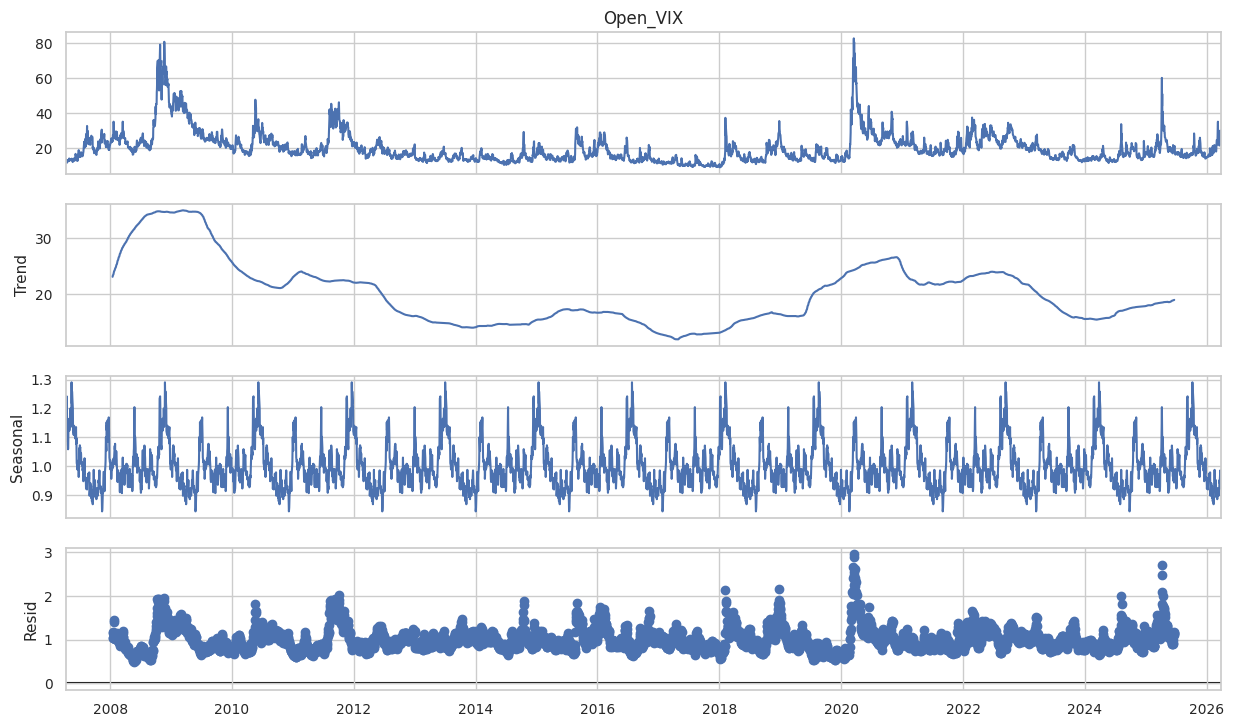

In [9]:
ts = data_eda["Open_VIX"]

# decomposition (multiplicative)
decomp = seasonal_decompose(ts, model='multiplicative', period=400)

# plot
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.show()

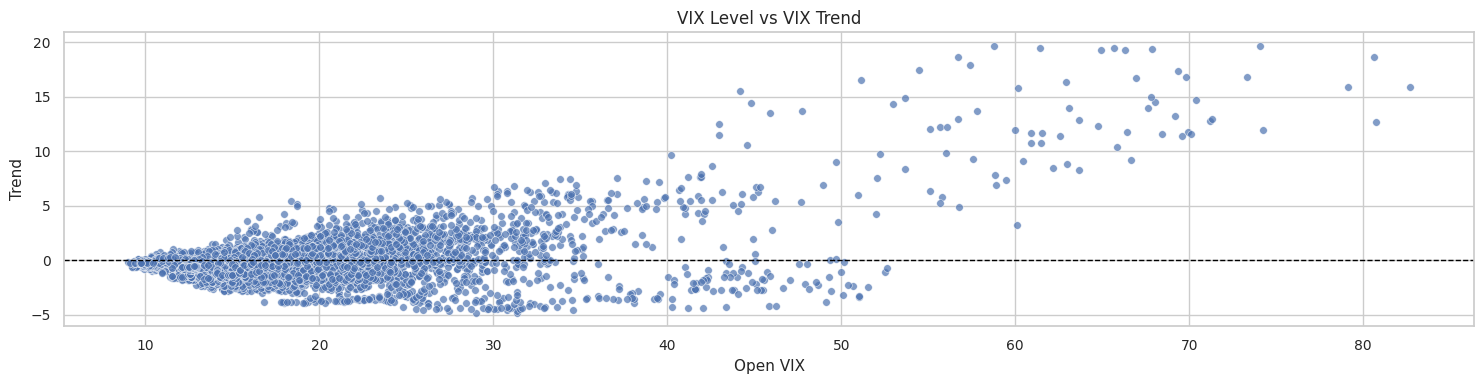

In [10]:
plt.figure(figsize=(15,4))

sns.scatterplot(
    data=data_eda,
    x="Open_VIX",
    y="VIX_Trend",
    alpha=0.7,
    s=30
)

plt.axhline(0, linestyle="--", linewidth=1, color="black")

plt.title("VIX Level vs VIX Trend")
plt.xlabel("Open VIX")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

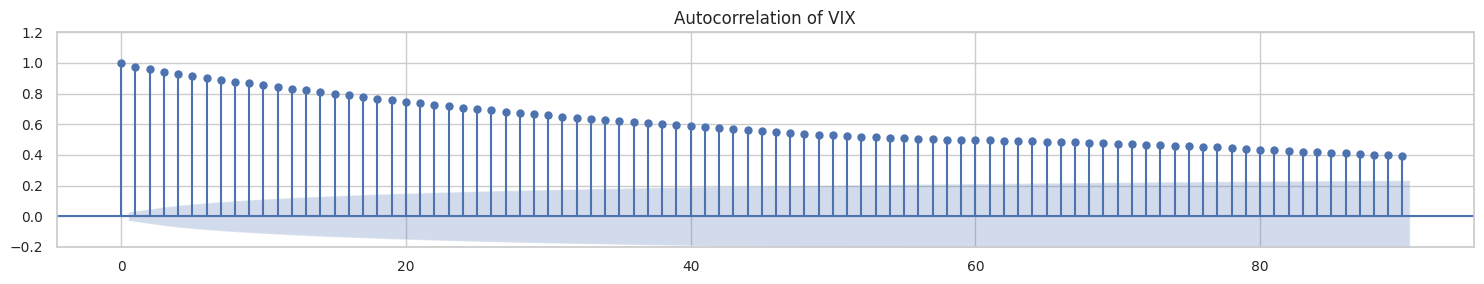

In [11]:
fig, ax = plt.subplots(figsize=(15,3))

plot_acf(data_eda["Open_VIX"], lags=90, ax=ax)

ax.set_title("Autocorrelation of VIX")
ax.set_ylim(top=1.2, bottom=-0.2)

plt.tight_layout()
plt.show()

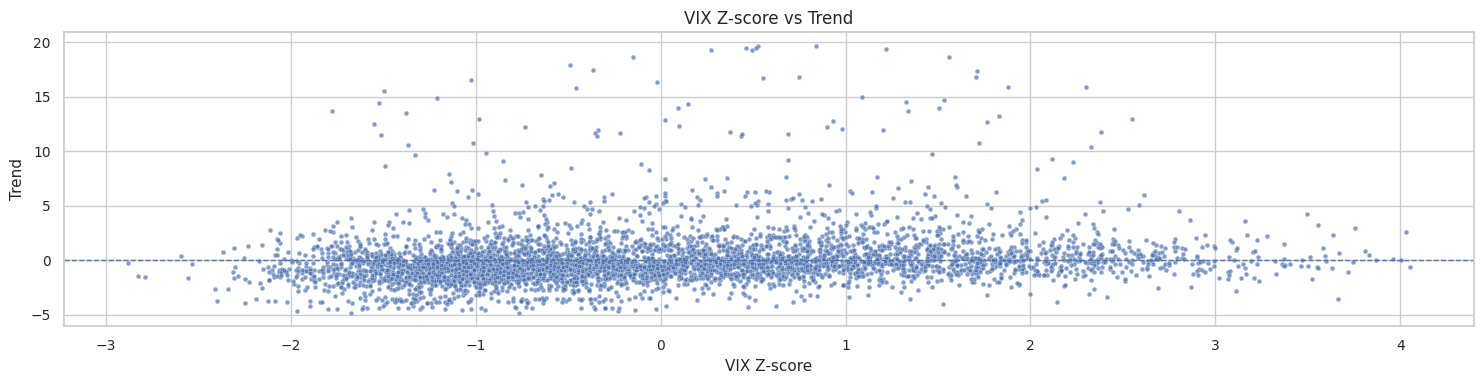

In [12]:
plt.figure(figsize=(15,4))

sns.scatterplot(
    data=df,
    x="VIX_Zscore",
    y="VIX_Trend",
    alpha=0.7,
    s=12
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("VIX Z-score vs Trend")
plt.xlabel("VIX Z-score")
plt.ylabel("Trend")

plt.tight_layout()
plt.show()

In [13]:
data_eda["VIX_5d"]=data_eda["Open_VIX"].shift(5)
data_eda["VIX_10d"]=data_eda["Open_VIX"].shift(10)
data_eda["VIX_15d"]=data_eda["Open_VIX"].shift(15)
data_eda["VIX_20d"]=data_eda["Open_VIX"].shift(20)
data_eda["VIX_40d"]=data_eda["Open_VIX"].shift(40)
data_eda["VIX_60d"]=data_eda["Open_VIX"].shift(60)

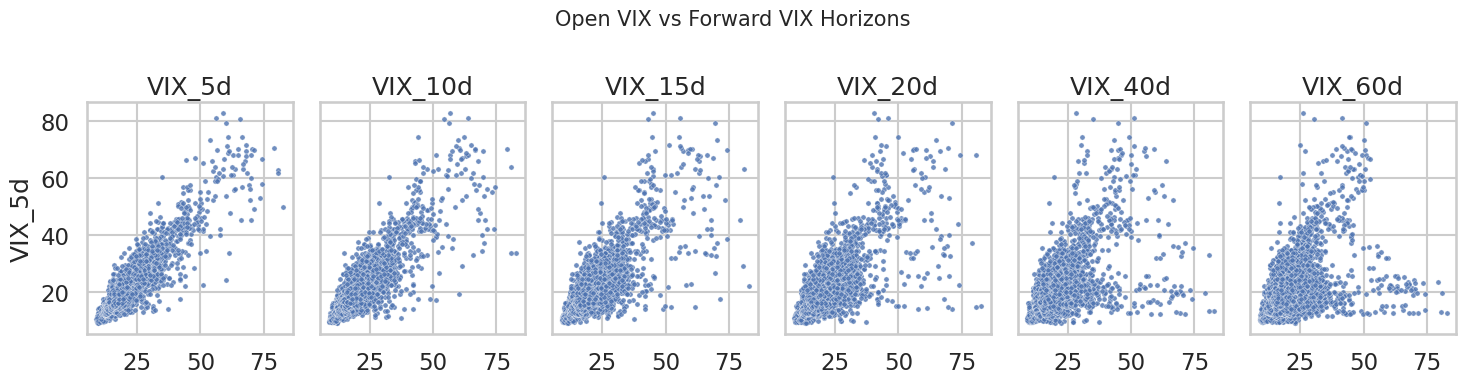

In [14]:
# @title
sns.set_theme(style="whitegrid", context="talk")

cols = ['VIX_5d', 'VIX_10d', 'VIX_15d', 'VIX_20d', 'VIX_40d','VIX_60d']

fig, axes = plt.subplots(1, len(cols), figsize=(15,4), sharey=True)

for i, col in enumerate(cols):
    sns.scatterplot(
        data=data_eda,
        x="Open_VIX",
        y=col,
        alpha=0.8,
        s=14,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")

fig.suptitle("Open VIX vs Forward VIX Horizons", fontsize=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2351/1036651007.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_trend = data_eda.groupby("VIX_regime")["VIX_fwd_5d"].mean()


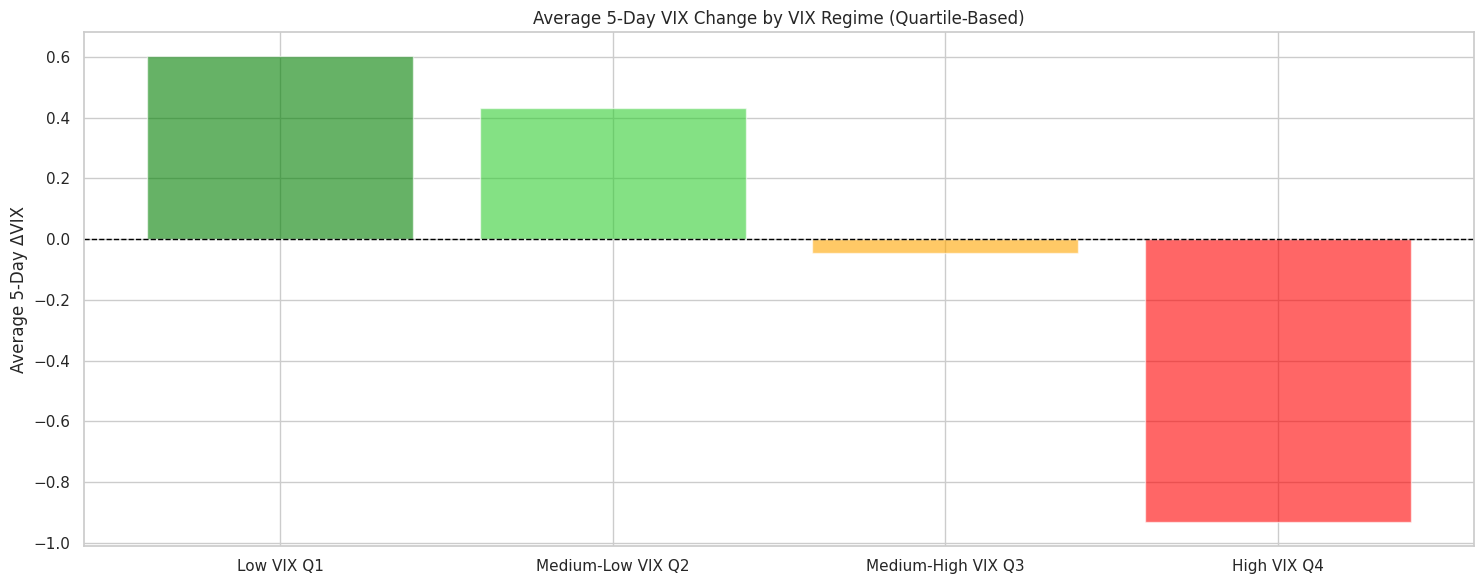

In [15]:
sns.set_theme(style="whitegrid")

# Forward 5-day VIX change
data_eda["VIX_fwd_5d"] = data_eda["Open_VIX"].shift(-5) - data_eda["Open_VIX"]

Q1 = data_eda["Open_VIX"].quantile(0.25)
Q2 = data_eda["Open_VIX"].quantile(0.50)
Q3 = data_eda["Open_VIX"].quantile(0.75)

bins = [data_eda["Open_VIX"].min()-1, Q1, Q2, Q3, data_eda["Open_VIX"].max()+1]
labels = ["Low VIX Q1", "Medium-Low VIX Q2" , "Medium-High VIX Q3", "High VIX Q4"]

data_eda["VIX_regime"] = pd.cut(data_eda["Open_VIX"], bins=bins, labels=labels)

regime_trend = data_eda.groupby("VIX_regime")["VIX_fwd_5d"].mean()

plt.figure(figsize=(15,6))

colors = {
    "Low VIX Q1":"green",
    "Medium-Low VIX Q2":"limegreen",
    "Medium-High VIX Q3":"orange",
    "High VIX Q4":"red"
}

for regime in labels:
    plt.bar(
        x=[regime],
        height=[regime_trend[regime]],
        color=colors[regime],
        alpha=0.6
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Average 5-Day ΔVIX")
plt.title("Average 5-Day VIX Change by VIX Regime (Quartile-Based)")
plt.tight_layout()
plt.show()

## VIX - SP

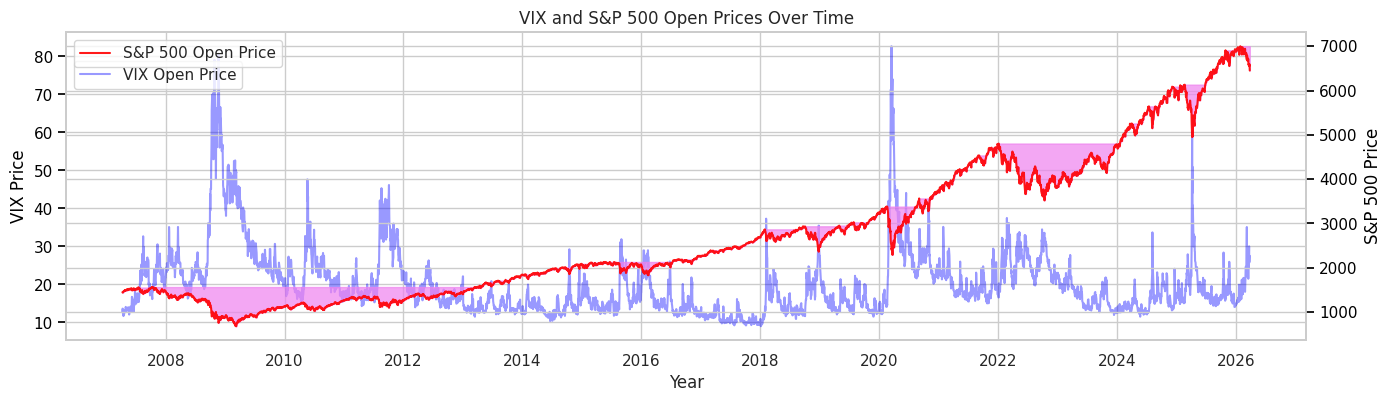

In [16]:
fig, ax1 = plt.subplots(figsize=(16,4))
data_eda["Historical_Maximum"]=data_eda["Open_SP500"].cummax()

# VIX
ax1.plot(data_eda.index, data_eda["Open_VIX"], label="VIX Open Price", color="blue", alpha=0.4)
ax1.set_xlabel("Year")
ax1.set_ylabel("VIX Price", color="black")
ax1.tick_params(axis='y', colors='black')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.93))

# S&P 500
ax2 = ax1.twinx()
ax2.plot(data_eda.index, data_eda["Open_SP500"], label="S&P 500 Open Price", color="red", alpha=0.9)
ax2.fill_between(
    data_eda.index,
    data_eda["Historical_Maximum"],
    data_eda["Open_SP500"],
    color="violet",
    alpha=0.7
)
ax2.set_ylabel("S&P 500 Price", color="black")
ax2.tick_params(axis='y', colors='black')
ax2.legend(loc='upper left')

plt.title("VIX and S&P 500 Open Prices Over Time")
plt.xticks(rotation=45)
plt.show()


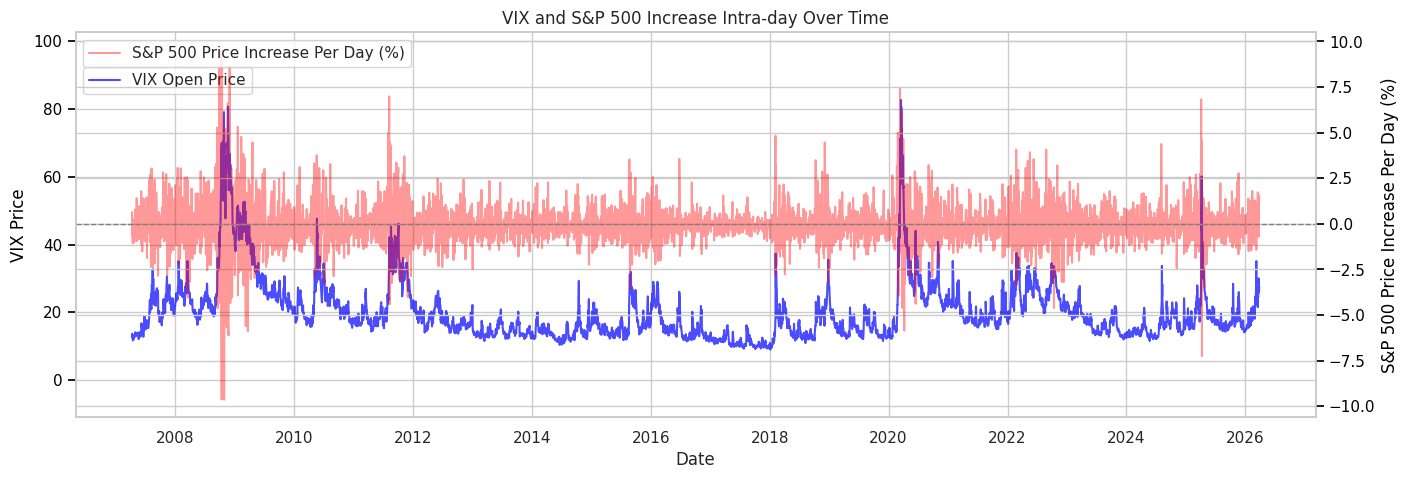

In [17]:
fig, ax1 = plt.subplots(figsize=(16,5))

# VIX
ax1.plot(data_eda.index, data_eda["Open_VIX"], label="VIX Open Price", color="blue", alpha=0.7)
ax1.set_xlabel("Date")
ax1.set_ylabel("VIX Price", color="black")
ax1.set_ylim(bottom=data_eda["Open_VIX"].min()-20, top=data_eda["Open_VIX"].max()+20)
ax1.tick_params(axis='y', colors='black')
ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.93))

# S&P 500
ax2 = ax1.twinx()
ax2.plot(data_eda.index, ((data_eda["Open_SP500"]/data_eda["Open_SP500"].shift(-1))*100-100), label="S&P 500 Price Increase Per Day (%)", color="red", alpha=0.4)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel("S&P 500 Price Increase Per Day (%)", color="black")
ax2.tick_params(axis='y', colors='black')
ax2.legend(loc='upper left')

plt.title("VIX and S&P 500 Increase Intra-day Over Time")
plt.xticks(rotation=45)
plt.show()

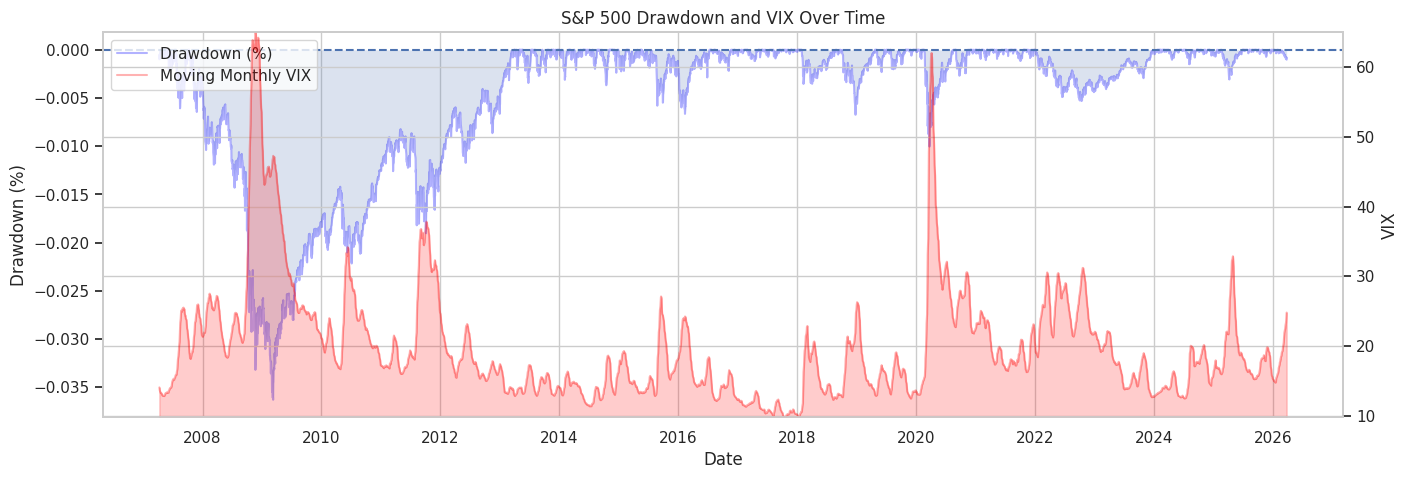

In [18]:
drawdown_pct = (data_eda["Drawdown"] / data_eda["Historical_Maximum"]) * 100

fig, ax1 = plt.subplots(figsize=(16,5))

ax1.plot(data_eda.index, drawdown_pct, label="Drawdown (%)", color="blue",alpha=0.3)

ax1.fill_between(data_eda.index,drawdown_pct,0,alpha=0.2)

ax1.axhline(0, linestyle='--', linewidth=1.5)

ax1.set_title("S&P 500 Drawdown and VIX Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Drawdown (%)")
ax1.grid(axis='y')

ax2 = ax1.twinx()

ax2.plot(data_eda.index, data_eda["VIX_MA_20"], label="Moving Monthly VIX", color="red",alpha=0.3)

ax2.fill_between( data_eda.index, data_eda["VIX_MA_20"],0,alpha=0.2,color="red")

ax2.set_ylabel("VIX")
ax2.set_ylim(data_eda["VIX_MA_20"].min(), data_eda["VIX_MA_20"].max())

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()


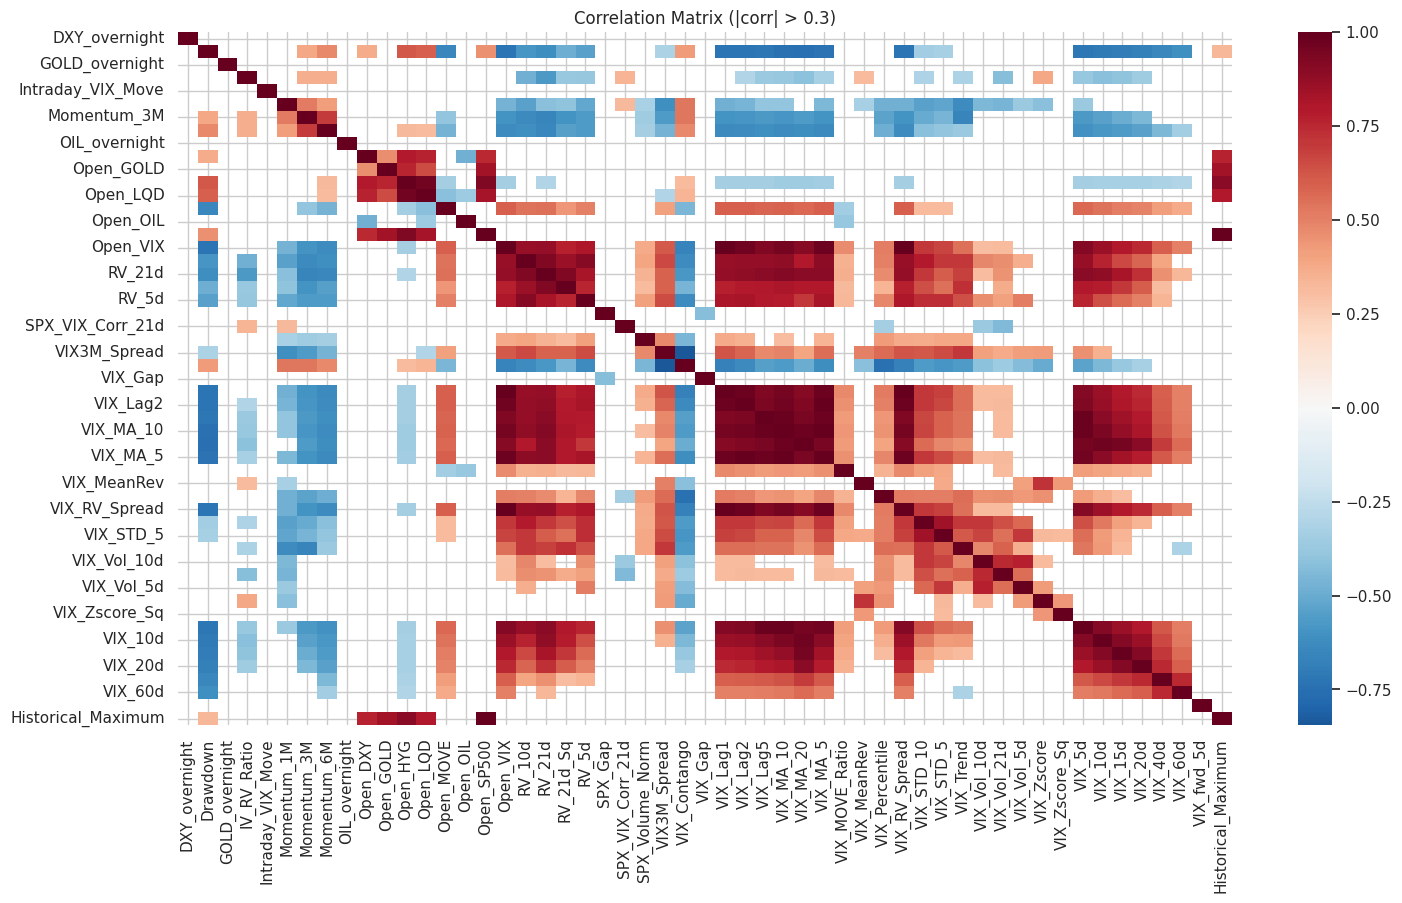

In [19]:
# just the numeric ones, pearson is not capable to be computed with categorical
numeric_df = data_eda.select_dtypes(include=['number'])

corr = numeric_df.corr()

corr_filtered = corr.where(np.abs(corr) > 0.3)
corr_filtered= corr_filtered

plt.figure(figsize=(17,9))
sns.heatmap(corr_filtered, cmap='RdBu_r', center=0)

plt.title("Correlation Matrix (|corr| > 0.3)")
plt.show()

/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int64, 1d, C), array(int64, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(int64, 1d, C), arr

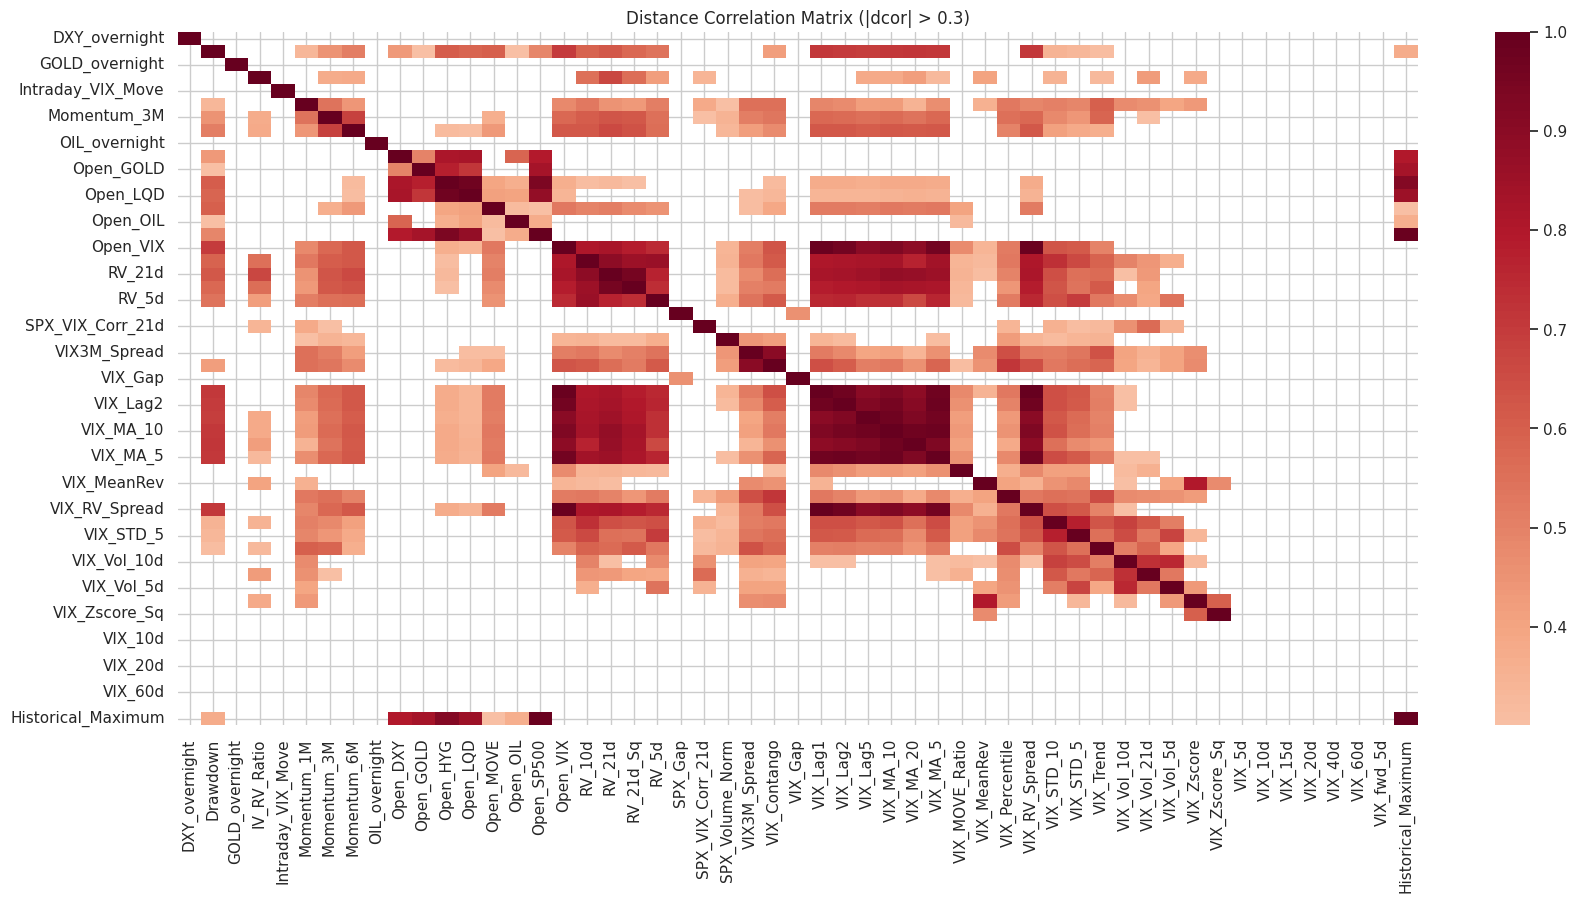

In [20]:
numeric_df = data_eda.select_dtypes(include=['number'])

cols = numeric_df.columns
n = len(cols)

# empty matrix
dcor_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)

# compute distance correlation (just numeric features)
for i in range(n):
    for j in range(i, n):
        x = numeric_df.iloc[:, i].values
        y = numeric_df.iloc[:, j].values

        val = dcor.distance_correlation(x, y)

        dcor_matrix.iloc[i, j] = val
        dcor_matrix.iloc[j, i] = val  # simetría

# filter low values
dcor_filtered = dcor_matrix.where(np.abs(dcor_matrix) > 0.3)

# plot
plt.figure(figsize=(20, 9))
sns.heatmap(dcor_filtered, cmap='RdBu_r', center=0)

plt.title("Distance Correlation Matrix (|dcor| > 0.3)")
plt.show()

## PCA

In [21]:
# select features that have at least one dcor > threshold with another feature
mask = dcor_filtered.any(axis=1)
selected_features = dcor_filtered.index[mask].drop('Open_VIX')

print("Features selected for PCA:", list(selected_features))

Features selected for PCA: ['DXY_overnight', 'Drawdown', 'GOLD_overnight', 'IV_RV_Ratio', 'Intraday_VIX_Move', 'Momentum_1M', 'Momentum_3M', 'Momentum_6M', 'OIL_overnight', 'Open_DXY', 'Open_GOLD', 'Open_HYG', 'Open_LQD', 'Open_MOVE', 'Open_OIL', 'Open_SP500', 'RV_10d', 'RV_21d', 'RV_21d_Sq', 'RV_5d', 'SPX_Gap', 'SPX_VIX_Corr_21d', 'SPX_Volume_Norm', 'VIX3M_Spread', 'VIX_Contango', 'VIX_Gap', 'VIX_Lag1', 'VIX_Lag2', 'VIX_Lag5', 'VIX_MA_10', 'VIX_MA_20', 'VIX_MA_5', 'VIX_MOVE_Ratio', 'VIX_MeanRev', 'VIX_Percentile', 'VIX_RV_Spread', 'VIX_STD_10', 'VIX_STD_5', 'VIX_Trend', 'VIX_Vol_10d', 'VIX_Vol_21d', 'VIX_Vol_5d', 'VIX_Zscore', 'VIX_Zscore_Sq', 'Historical_Maximum']


In [22]:
X = numeric_df[selected_features].dropna()  # remove rows with NaN and target feature

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# choose number of components (14 comp. contain then 87% of original data)
pca = PCA(n_components=14)
X_pca = pca.fit(X_scaled)

# explained variance
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_,2))
print("Cumulative explained variance:", np.round(np.cumsum(pca.explained_variance_ratio_),2))
print("Dimensionality reduction", len(df.columns.drop("Open_VIX")), "->", 14, "|", round(14/len(df.columns.drop("Open_VIX"))*100,2), "%")

Explained variance ratio: [0.36 0.12 0.08 0.05 0.04 0.03 0.03 0.03 0.02 0.02 0.02 0.02 0.02 0.02]
Cumulative explained variance: [0.36 0.48 0.57 0.62 0.66 0.69 0.72 0.75 0.77 0.8  0.82 0.84 0.86 0.87]
Dimensionality reduction 44 -> 14 | 31.82 %


In [24]:
# PCA loadings (feature contribution to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("\nPCA Loadings:")
print(loadings)


PCA Loadings:
                         PC1       PC2       PC3       PC4       PC5  \
DXY_overnight       0.000666  0.011137 -0.011620 -0.007990  0.019062   
Drawdown           -0.163681  0.204222  0.094154  0.177702 -0.022056   
GOLD_overnight      0.020086  0.006141 -0.003763  0.002134 -0.043908   
IV_RV_Ratio        -0.101543  0.035136  0.155078 -0.352394  0.235860   
Intraday_VIX_Move   0.026142  0.044928  0.085071 -0.020735  0.012776   
Momentum_1M        -0.148016 -0.086945 -0.165590 -0.031148  0.174007   
Momentum_3M        -0.174811 -0.004665  0.006141 -0.029027  0.188087   
Momentum_6M        -0.169913  0.049701  0.046681  0.026092  0.152756   
OIL_overnight       0.005705  0.007735 -0.025119  0.011636 -0.010978   
Open_DXY           -0.042607  0.311418 -0.175513 -0.064471 -0.074580   
Open_GOLD          -0.045549  0.295356 -0.164548 -0.137533 -0.106599   
Open_HYG           -0.097667  0.366336 -0.137795 -0.038554 -0.027751   
Open_LQD           -0.085965  0.354467 -0.144812 

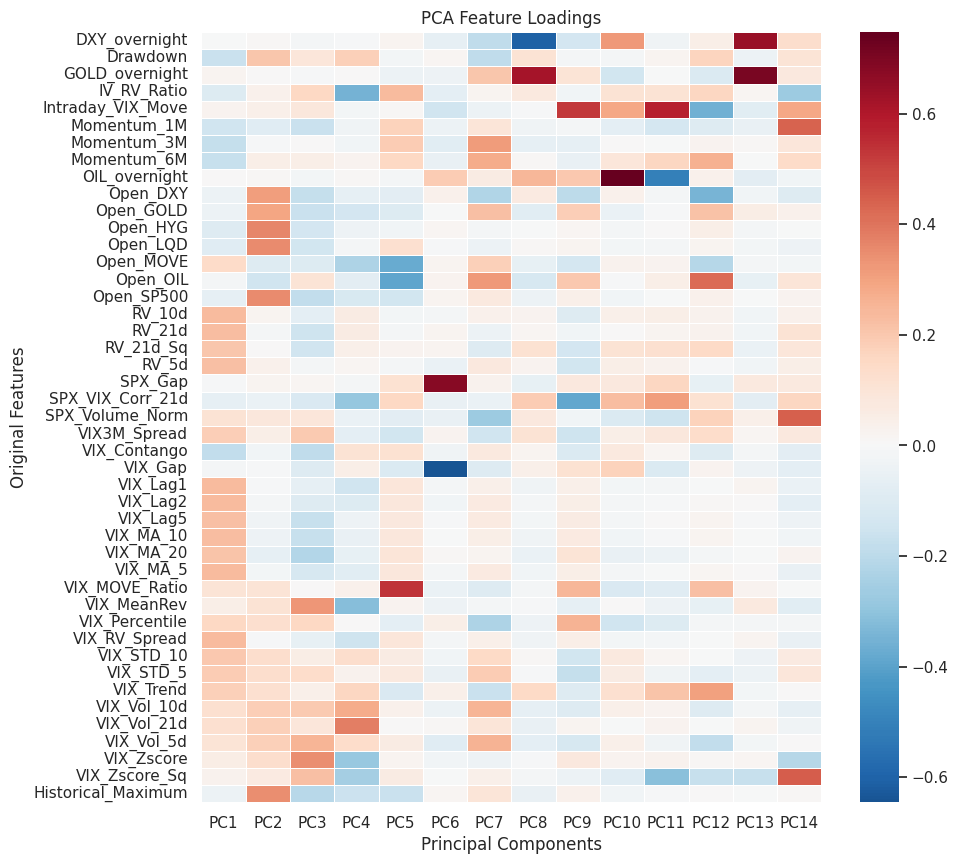

In [25]:
plt.figure(figsize=(10,10))
sns.heatmap(loadings, cmap='RdBu_r', center=0,linewidths=0.5)
plt.title("PCA Feature Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.show()